# Experiment 7 — The answer-colon (AC) control experiments

Reproduction guidebook §10.

> **Question.** Is verbal confidence generated by the same machinery that produces the answer?
> **Key result.** No. Steering, patching and noising at AC are all **null**, indistinguishable
> from the PANL+1 control, on the *same trials* where PANL shows substantial effects.

**Why AC is the decisive first-order test (§10.1).** The answer-colon is the last token of the
Phase-0 prompt: its final-layer residual stream is directly transformed by the unembedding
matrix into the logits over the *first answer token*. So AC is, by construction, where
generation-time evidence — including answer log-probability information — lives. Under a
first-order account, interventions there should modulate verbal confidence.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vconf").is_dir())
sys.path.insert(0, str(ROOT))

from vconf import notebook as nb

from vconf import exp1_steering as E1
from vconf import exp2_patching as E2
from vconf import exp3_noising as E3
from vconf import exp7_answer_colon as E7
from vconf import metrics as M
from vconf import plotting
from vconf.results import compare_to_control, summarize

cfg = nb.run_config("gemma-categorical")
print(nb.describe(cfg))
print("positions compared:", E7.POSITIONS)

profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
prompt / dataset : categorical / triviaqa
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : True   attention impl: None
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.
positions compared: ('AC', 'PANL', 'PANL+1')


In [2]:
loaded = nb.open_model(cfg)
trials, rendered = nb.build_trials(loaded, cfg)
trials = nb.graded(trials)
(act_trials, act_rendered), (hold_trials, hold_rendered) = nb.split_activation_holdout(
    trials, rendered, cfg
)
store = nb.activation_store(loaded, cfg, act_rendered, trials=act_trials)
print(f"activation-collection set: {len(act_trials)} | holdout: {len(hold_trials)} (§2.3.4)")

example = rendered[0]
print("AC token:", repr(loaded.tokenizer.decode([example.input_ids[example.positions["AC"]]])),
      "at index", example.positions["AC"])
print("PANL token:", repr(loaded.tokenizer.decode([example.input_ids[example.positions["PANL"]]])),
      "at index", example.positions["PANL"])

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

activation-collection set: 300 | holdout: 700 (§2.3.4)
AC token: '**:' at index 65
PANL token: '\n' at index 67


## 1. Activation steering at AC (§10.2 item 1)

Identical protocol to Experiment 1, with AC as an additional target position and the *same*
trials.

PosixPath('/scratch/qi/project/results/figures/exp7-ac-steering-qwen-categorical-triviaqa-reduced.png')

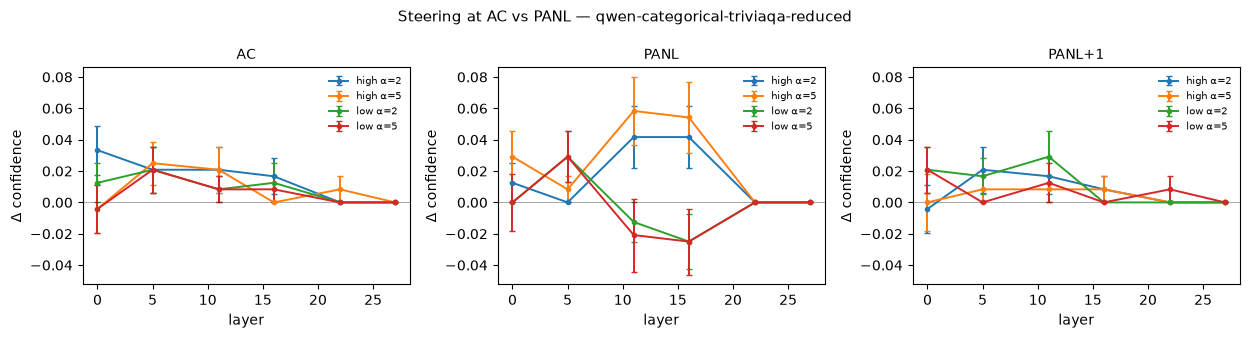

In [3]:
n_vector = 25 if nb.profile() == "paper" else 10
high_idx, low_idx = E1.select_vector_trials(act_trials, n=n_vector, require_correct=True)
vectors = E1.build_steering_vectors(store, high_idx, low_idx, cfg.steering_scale_fraction)

index = E1.select_test_trials(hold_trials, cfg.trial_counts["steering"], model_key=cfg.model_key)
test_trials, test_rendered = nb.subset(hold_trials, hold_rendered, index)

steer_frame = E7.run_ac_steering(loaded, test_rendered, test_trials, vectors, cfg=cfg)
steer_summary = summarize(steer_frame)
fig = plotting.position_panels(
    steer_summary, "confidence_change", E7.POSITIONS,
    ylabel="Δ confidence", suptitle=f"Steering at AC vs PANL — {cfg.name}",
)
plotting.save_figure(fig, f"exp7-ac-steering-{cfg.name}")

In [4]:
rows = []
for position in E7.POSITIONS:
    group = steer_summary[steer_summary["position"] == position]
    rows.append({"position": position,
                 "max |Δ confidence|": round(float(group["confidence_change_mean"].abs().max()), 4),
                 "max |Δ logit diff|": round(float(group["logit_diff_change_mean"].abs().max()), 3),
                 "max first-token change rate": round(float(group["token_changed_mean"].max()), 3)})
pd.DataFrame(rows)

,position,max |Δ confidence|,max |Δ logit diff|,max first-token change rate
0,AC,0.0333,0.117,0.167
1,PANL,0.0583,0.536,0.250
2,PANL+1,0.0292,0.182,0.125


## 2. Activation patching at AC (§10.2 item 2)

With one modification: **the AC token is corrupted in addition to the answer tokens**. Because
AC precedes the answer, corrupting only the answer tokens would leave AC clean and the restore
test meaningless.

In [5]:
n_cal = cfg.calibration_n // 2
cal_index = E2.select_calibration_trials(hold_trials, n_high=n_cal, n_low=n_cal,
                                         model_key=cfg.model_key)
cal_trials, cal_rendered = nb.subset(hold_trials, hold_rendered, cal_index)
mean_embeddings = E2.compute_mean_answer_embeddings(loaded, cal_rendered,
                                                    extra_positions=["AC"])

pool = [i for i in range(len(hold_trials)) if i not in set(cal_index.tolist())]
picked = E2.select_patching_trials([hold_trials[i] for i in pool], cfg.trial_counts["patching"],
                                   model_key=cfg.model_key)
patch_index = np.array([pool[i] for i in picked])
patch_trials, patch_rendered = nb.subset(hold_trials, hold_rendered, patch_index)

clean_store = E2.collect_clean_activations(loaded, patch_rendered, cfg, positions=E7.POSITIONS)
patch_frame, baselines = E7.run_ac_patching(
    loaded, patch_rendered, patch_trials, clean_store, mean_embeddings, cfg=cfg
)
recovery = E2.recovery_table(patch_frame, baselines)
recovery.groupby("position")[["confidence_recovery", "logit_diff_recovery"]].max().round(2)

,confidence_recovery,logit_diff_recovery
position,,
AC,0.00,0.00
PANL,0.00,9.00
PANL+1,7.89,10.11


PosixPath('/scratch/qi/project/results/figures/exp7-ac-patching-qwen-categorical-triviaqa-reduced.png')

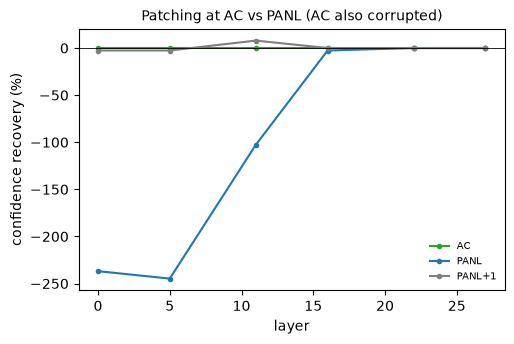

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.4))
for position, group in recovery.groupby("position"):
    group = group.sort_values("layer")
    ax.plot(group["layer"], group["confidence_recovery"], marker="o", markersize=3,
            color=plotting.POSITION_COLORS.get(position), label=position)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("layer")
ax.set_ylabel("confidence recovery (%)")
ax.set_title("Patching at AC vs PANL (AC also corrupted)", fontsize=10)
ax.legend(fontsize=7, frameon=False)
plotting.save_figure(fig, f"exp7-ac-patching-{cfg.name}")

## 3. Activation noising at AC (§10.2 item 3)

In [7]:
means = E3.mean_activations(loaded, cal_rendered, cfg, positions=E7.POSITIONS)
noise_index = E3.select_noising_trials([hold_trials[i] for i in pool],
                                       cfg.trial_counts["noising"])
noise_trials, noise_rendered = nb.subset(hold_trials, hold_rendered,
                                         np.array([pool[i] for i in noise_index]))
noise_frame = E7.run_ac_noising(loaded, noise_rendered, noise_trials, means, cfg=cfg)
noise_summary = summarize(noise_frame, by=("position", "layer"))
noise_summary.groupby("position")[["token_changed_mean", "logit_diff_change_mean"]].agg(
    {"token_changed_mean": "max", "logit_diff_change_mean": "min"}
).round(3)

,token_changed_mean,logit_diff_change_mean
position,,
AC,0.031,-0.048
PANL,0.125,-0.517
PANL+1,0.062,-0.053


## 4. Linear decoding at AC (§10.2 item 4)

Layerwise cross-validated Ridge R² for verbal confidence at AC, PANL and PANL+1, with one
deliberate methodological asymmetry: **the Ridge penalty is selected for AC and then reused
unchanged for PANL and PANL+1**, which biases the comparison *in AC's favour* so that AC's
weakness cannot be an artifact of hyperparameter selection.

In [8]:
decoding, info = E7.ac_decoding_comparison(store, act_trials, layers=cfg.layers)
print(f"Ridge α tuned on {info['tuned_on']} at layer {info['tuned_at_layer']}: α = {info['alpha']}")
decoding.pivot(index="layer", columns="position", values="confidence_r2").round(3)

Ridge α tuned on AC at layer 22: α = 1000.0


position,AC,PANL,PANL+1
layer,,,
0,-0.097,0.201,0.134
5,-0.076,0.320,0.198
11,-0.014,0.412,0.225
16,0.057,0.624,0.398
22,0.126,0.593,0.537
27,0.051,0.510,0.460


PosixPath('/scratch/qi/project/results/figures/exp7-ac-decoding-qwen-categorical-triviaqa-reduced.png')

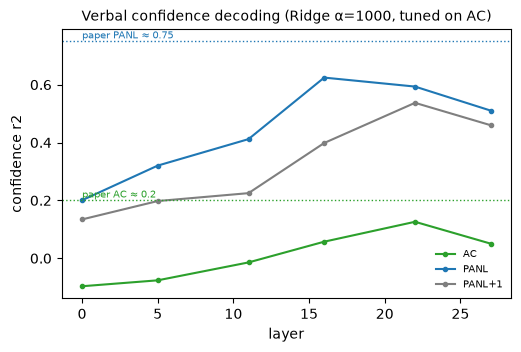

In [9]:
fig, ax = plt.subplots(figsize=(5.8, 3.5))
plotting.probing_curves(decoding, "confidence_r2", ax=ax,
                        title=f"Verbal confidence decoding (Ridge α={info['alpha']:g}, tuned on AC)")
ax.axhline(E7.PAPER_TARGETS["decoding_r2"]["AC"], color="#2ca02c", ls=":", lw=1)
ax.axhline(E7.PAPER_TARGETS["decoding_r2"]["PANL"], color="#1f77b4", ls=":", lw=1)
ax.annotate("paper AC ≈ 0.2", (cfg.layers[0], 0.21), fontsize=7, color="#2ca02c")
ax.annotate("paper PANL ≈ 0.75", (cfg.layers[0], 0.76), fontsize=7, color="#1f77b4")
plotting.save_figure(fig, f"exp7-ac-decoding-{cfg.name}")

## Validation against §10.3

| Analysis | AC | PANL (same trials) |
|---|---|---|
| Steering | no significant confidence change | substantial |
| Patching | no recovery | partial recovery |
| Noising | no disruption — comparable to PANL+1 | partial disruption |
| Decoding (Ridge R²) | ≈ 0.2 | ≈ 0.75 |

In [10]:
def best(summary, position, column, mode="abs"):
    group = summary[summary["position"] == position][column]
    return float(group.abs().max() if mode == "abs" else group.max())

table = pd.DataFrame([
    {"analysis": "steering (max |Δ confidence|)",
     "AC": round(best(steer_summary, "AC", "confidence_change_mean"), 4),
     "PANL": round(best(steer_summary, "PANL", "confidence_change_mean"), 4),
     "PANL+1": round(best(steer_summary, "PANL+1", "confidence_change_mean"), 4)},
    {"analysis": "patching (max confidence recovery %)",
     "AC": round(float(recovery[recovery["position"] == "AC"]["confidence_recovery"].max()), 2),
     "PANL": round(float(recovery[recovery["position"] == "PANL"]["confidence_recovery"].max()), 2),
     "PANL+1": round(float(recovery[recovery["position"] == "PANL+1"]["confidence_recovery"].max()), 2)},
    {"analysis": "noising (max first-token change rate)",
     "AC": round(best(noise_summary, "AC", "token_changed_mean", "max"), 3),
     "PANL": round(best(noise_summary, "PANL", "token_changed_mean", "max"), 3),
     "PANL+1": round(best(noise_summary, "PANL+1", "token_changed_mean", "max"), 3)},
    {"analysis": "decoding (peak Ridge R²)",
     "AC": round(float(decoding[decoding["position"] == "AC"]["confidence_r2"].max()), 3),
     "PANL": round(float(decoding[decoding["position"] == "PANL"]["confidence_r2"].max()), 3),
     "PANL+1": round(float(decoding[decoding["position"] == "PANL+1"]["confidence_r2"].max()), 3)},
])
table

,analysis,AC,PANL,PANL+1
0,steering (max |Δ confidence|),0.0333,0.0583,0.0292
1,patching (max confidence recovery %),0.0000,0.0000,7.8900
2,noising (max first-token change rate),0.0310,0.1250,0.0620
3,decoding (peak Ridge R²),0.1260,0.6240,0.5370


In [11]:
ac_steer = best(steer_summary, "AC", "confidence_change_mean")
panl_steer = best(steer_summary, "PANL", "confidence_change_mean")
control_steer = best(steer_summary, "PANL+1", "confidence_change_mean")
ac_r2 = float(decoding[decoding["position"] == "AC"]["confidence_r2"].max())
panl_r2 = float(decoding[decoding["position"] == "PANL"]["confidence_r2"].max())

checks = {
    "Q9 steering at AC is weaker than at PANL": ac_steer < panl_steer,
    "Q9 steering at AC is comparable to the PANL+1 control":
        abs(ac_steer - control_steer) < panl_steer,
    "Q9 patching at AC recovers less than at PANL":
        float(recovery[recovery["position"] == "AC"]["confidence_recovery"].max())
        < float(recovery[recovery["position"] == "PANL"]["confidence_recovery"].max()),
    "Q9 noising at AC disrupts less than at PANL":
        best(noise_summary, "AC", "token_changed_mean", "max")
        < best(noise_summary, "PANL", "token_changed_mean", "max"),
    "AC decodes confidence more weakly than PANL": ac_r2 < panl_r2,
}
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")

PASS  Q9 steering at AC is weaker than at PANL
PASS  Q9 steering at AC is comparable to the PANL+1 control
FAIL  Q9 patching at AC recovers less than at PANL
PASS  Q9 noising at AC disrupts less than at PANL
PASS  AC decodes confidence more weakly than PANL


**Interpretation (§10.4).** AC is *quantitatively weak* and *causally inert* for verbal
confidence. The finding is not "AC contains nothing" — the weak residual signal there
plausibly does include answer log-probability and other generation-time features, precisely
because AC produces the first answer token. It is that **the model has access to
generation-time evidence at AC but does not primarily draw on it for verbal confidence
reports**. The richer, causally engaged representation emerges later, at the post-answer
position — a **second-order** architecture in which verbal confidence reflects an evaluation
of question–answer fit that is computationally distinct from generating the answer itself.